<a href="https://colab.research.google.com/github/benasphy/Random-Forest/blob/main/Untitled283.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,accuracy_score

In [20]:
gold_data = pd.read_csv('/content/gld_price_data.csv', parse_dates=['Date']) # Parse the 'Date' column as dates
correlation = gold_data.corr()

In [21]:
correlation = gold_data.corr()

<Axes: >

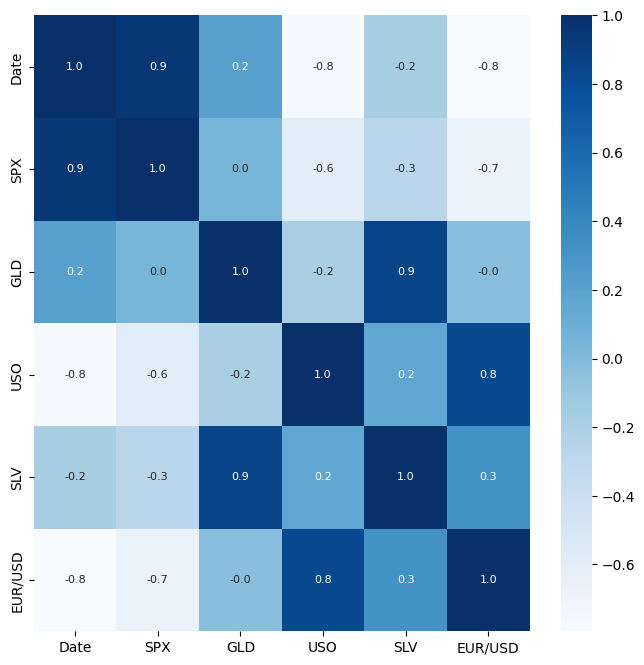

In [22]:
plt.figure(figsize=(8, 8))
sns.heatmap(correlation, cbar=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')

In [23]:
print(correlation['GLD'])

Date       0.209118
SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


<ipython-input-24-fbf216c10769>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gold_data['GLD'], color='g')


<Axes: xlabel='GLD', ylabel='Density'>

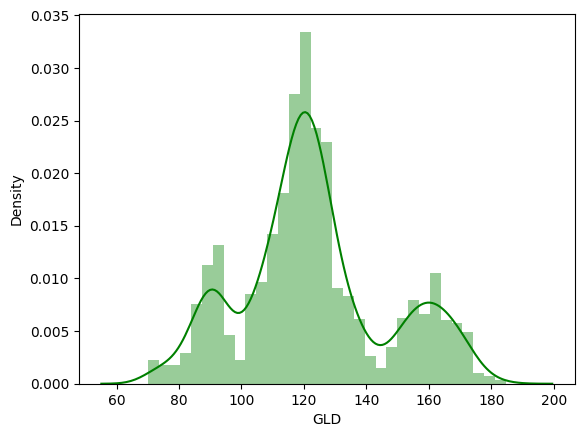

In [24]:
#checking the distribution
sns.distplot(gold_data['GLD'], color='g')

In [25]:
X = gold_data.drop(['GLD', 'Date'], axis=1)
y = gold_data['GLD']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [29]:
regressor = RandomForestRegressor(n_estimators=100)
regressor.fit(X_train, y_train)

RandomForestRegressor()

In [30]:
y_pred = regressor.predict(X_test)

In [31]:
r2 = r2_score(y_test, y_pred)
r2

0.9897880898398945

Comparing the Actual Values and Predicted Values in a Plot

In [32]:
Y_test = list(y_test)

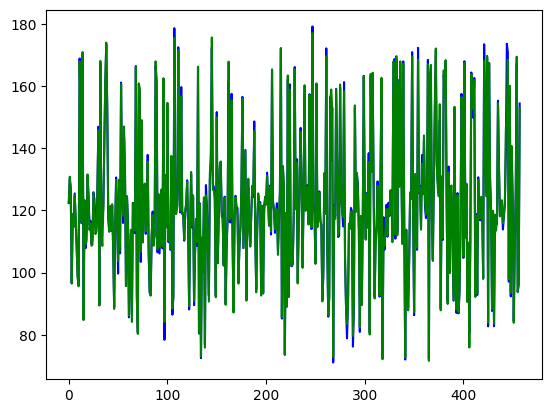

In [33]:
plt.plot(Y_test, color='blue', label = 'Actual Value')
plt.plot(y_pred, color='green', label = 'Predicted Value')